In [15]:
# IMPORTS
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [16]:
# CONFIG AND HYPERPARAMETERS
DATASET_PATH    = "../../Dataset/day_approach_maskedID_timeseries.csv"
SEQUENCE_LENGTH = 14
HIDDEN_SIZE     = 32
EPOCHS          = 500
LR              = 1e-3
BATCH_SIZE      = 512
PATIENCE        = 20
POS_WEIGHT      = 50.0
TARGET_SENSITIVITY = 0.65
TEST_SIZE       = 0.2
VAL_RATIO       = 0.5
OUTPUT_MODEL    = "gru_14day_high_sensitivity.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [17]:
# LOAD AND INSPECT DATA
df = pd.read_csv(DATASET_PATH, parse_dates=["Date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (42766, 73)


C:\Users\marcj\AppData\Local\Temp\ipykernel_2560\3823608543.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(DATASET_PATH, parse_dates=["Date"])


,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.00,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1.0,0.0,0.10,0.00,0.17,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,1.08,0.08,0.00,0.18,...,0.0,0.0,0.0,0.0,0.11,0.00,0.17,0,0,4


In [18]:
# SELECT FEATURES AND BASIC STATS
BASE_FEATURES = [
    "Athlete ID", "Date", "injury",
    "nr. sessions", "total km", "km Z3-4",
    "km Z5-T1-T2", "km sprinting", "strength training",
    "hours alternative", "perceived exertion",
    "perceived trainingSuccess", "perceived recovery",
]

df = df[BASE_FEATURES].sort_values(["Athlete ID", "Date"]).copy()
FEATURE_COLS = [c for c in df.columns if c not in ["injury", "Athlete ID", "Date"]]

print(f"Feature columns: {FEATURE_COLS}")
print(f"Total records  : {len(df)}")
print(f"Injuries       : {(df['injury'] == 1).sum()}")
print(f"Non-injuries   : {(df['injury'] == 0).sum()}")

Feature columns: ['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting', 'strength training', 'hours alternative', 'perceived exertion', 'perceived trainingSuccess', 'perceived recovery']
Total records  : 42766
Injuries       : 583
Non-injuries   : 42183


In [19]:
# BUILD SEQUENCES
def prepare_sequences(df, sequence_length, feature_cols):
    X_list, y_list = [], []
    for _, athlete_df in df.groupby("Athlete ID", sort=False):
        athlete_df = athlete_df.sort_values("Date")
        features = athlete_df[feature_cols].values.astype(np.float32)
        labels   = athlete_df["injury"].values.astype(np.float32)
        for start in range(len(athlete_df) - sequence_length + 1):
            end = start + sequence_length
            X_list.append(features[start:end])
            y_list.append(labels[end - 1])
    return np.asarray(X_list, dtype=np.float32), np.asarray(y_list, dtype=np.float32)

X, y = prepare_sequences(df, SEQUENCE_LENGTH, FEATURE_COLS)
print(f"Sequences generated : {len(X)}")
print(f"Injury sequences    : {int((y == 1).sum())}")
print(f"Non-injury sequences: {int((y == 0).sum())}")

Sequences generated : 41804
Injury sequences    : 552
Non-injury sequences: 41252


In [20]:
# TRAIN/VAL/TEST SPLIT + NORMALISATION
def split_and_normalize(X, y, test_size=0.2, val_ratio=0.5, random_state=42):
    X_train, X_valtest, y_train, y_valtest = train_test_split(
        X, y, test_size=test_size, random_state=random_state,
        stratify=y if len(np.unique(y)) > 1 else None,
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_valtest, y_valtest, test_size=val_ratio, random_state=random_state,
        stratify=y_valtest if len(np.unique(y_valtest)) > 1 else None,
    )
    mu    = X_train.mean(axis=(0, 1), keepdims=True)
    sigma = X_train.std(axis=(0, 1),  keepdims=True)
    sigma[sigma == 0] = 1.0
    X_train = (X_train - mu) / sigma
    X_val   = (X_val   - mu) / sigma
    X_test  = (X_test  - mu) / sigma
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = split_and_normalize(
    X, y, test_size=TEST_SIZE, val_ratio=VAL_RATIO
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 33443 | Val: 4180 | Test: 4181


In [21]:
# DATALOADERS
def make_tensor_loader(X, y, batch_size, shuffle):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_tensor_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_tensor_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_tensor_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

In [22]:
# MODEL DEFINITION
class GRUModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])

model     = GRUModel(input_size=X_train.shape[2], hidden_size=HIDDEN_SIZE).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print(model)

GRUModel(
  (gru): GRU(10, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [23]:
# EVALUATE HELPER
def evaluate(loader, model, criterion, threshold=0.5):
    model.eval()
    total_loss, total_count = 0.0, 0
    all_probs, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            total_loss  += criterion(logits, yb).item() * xb.size(0)
            total_count += yb.size(0)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_true.extend(yb.cpu().numpy().astype(int).flatten())
    avg_loss = total_loss / max(total_count, 1)
    probs = np.array(all_probs)
    preds = (probs >= threshold).astype(int)
    return avg_loss, np.array(all_true), probs, preds

In [24]:
# TRAINING LOOP
best_val_loss = float("inf")
best_state    = copy.deepcopy(model.state_dict())
patience_count = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_count = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss  += loss.item() * xb.size(0)
        train_count += yb.size(0)

    train_loss /= max(train_count, 1)
    val_loss, _, _, _ = evaluate(val_loader, model, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print("Training complete.")

Early stopping at epoch 35
Training complete.


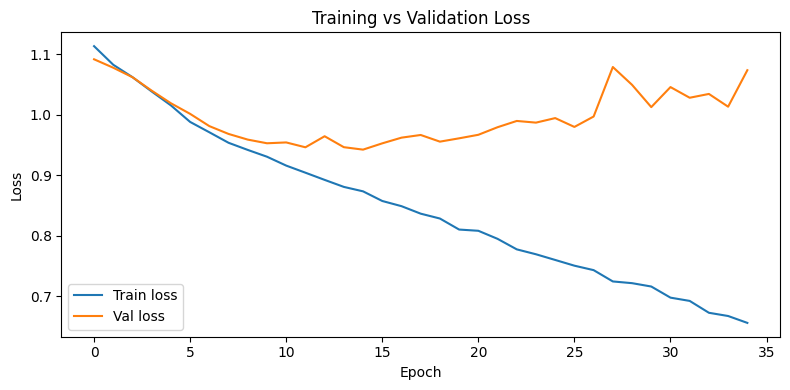

In [29]:
# LOSS CURVE
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# THRESHOLD SELECTION ON VALIDATION SET
def find_threshold_for_sensitivity(y_true, y_probs, target_sensitivity=0.65):
    thresholds = np.linspace(0.01, 0.99, 199)
    best_thresh, best_diff = thresholds[0], float("inf")
    best_sens, best_spec   = 0.0, 0.0
    for thresh in thresholds:
        preds = (y_probs >= thresh).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()
        tn = ((preds == 0) & (y_true == 0)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        diff = abs(sens - target_sensitivity)
        if diff < best_diff:
            best_diff, best_thresh, best_sens, best_spec = diff, thresh, sens, spec
    return best_thresh, best_sens, best_spec

_, _, y_val_probs, _ = evaluate(val_loader, model, criterion)
threshold, val_sens, val_spec = find_threshold_for_sensitivity(
    y_val, y_val_probs, target_sensitivity=TARGET_SENSITIVITY
)
print(f"Selected threshold : {threshold:.2f}")
print(f"Val sensitivity    : {val_sens:.1%}")
print(f"Val specificity    : {val_spec:.1%}")

Selected threshold : 0.37
Val sensitivity    : 65.5%
Val specificity    : 68.2%


In [31]:
# FINAL EVALUATION ON TEST SET
_, y_test_true, y_test_probs, y_test_pred = evaluate(test_loader, model, criterion, threshold=threshold)

tp = ((y_test_pred == 1) & (y_test_true == 1)).sum()
fn = ((y_test_pred == 0) & (y_test_true == 1)).sum()
tn = ((y_test_pred == 0) & (y_test_true == 0)).sum()
fp = ((y_test_pred == 1) & (y_test_true == 0)).sum()

sensitivity  = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0
precision    = tp / (tp + fp) if (tp + fp) > 0 else 0
f1           = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
balanced_acc = (sensitivity + specificity) / 2
roc_auc      = roc_auc_score(y_test_true, y_test_probs)
accuracy     = accuracy_score(y_test_true, y_test_pred)

results = dict(
    threshold=threshold, sensitivity=sensitivity, specificity=specificity,
    precision=precision, f1=f1, balanced_accuracy=balanced_acc,
    roc_auc=roc_auc, accuracy=accuracy,
    tp=int(tp), fn=int(fn), tn=int(tn), fp=int(fp),
)

print("=== Test Results ===")
for k, v in results.items():
    print(f"  {k:20s}: {v:.3f}" if isinstance(v, float) else f"  {k:20s}: {v}")

=== Test Results ===
  threshold           : 0.366
  sensitivity         : 0.655
  specificity         : 0.666
  precision           : 0.025
  f1                  : 0.049
  balanced_accuracy   : 0.660
  roc_auc             : 0.753
  accuracy            : 0.666
  tp                  : 36
  fn                  : 19
  tn                  : 2749
  fp                  : 1377


In [32]:
# SAVE MODEL
torch.save(model.state_dict(), OUTPUT_MODEL)
print(f"Model saved to: {os.path.abspath(OUTPUT_MODEL)}")

Model saved to: c:\Users\marcj\Desktop\Marc\ESTUDIS\UB\4T CURS\2N SEM\IA\PROJECT\AI_Project_Injury_Prediction\Algorithms\GRU\gru_14day_high_sensitivity.pt


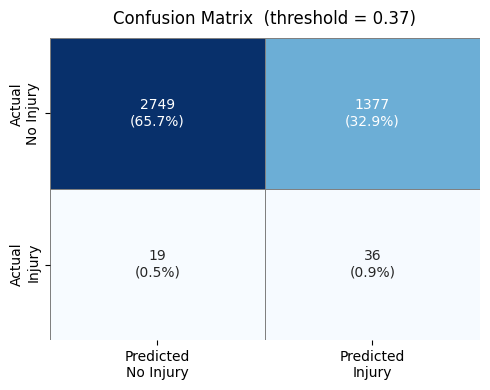

In [33]:
# CONFUSION MATRIX
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

cm = np.array([[tn, fp], [fn, tp]])
labels = [["TN", "FP"], ["FN", "TP"]]
annot  = np.array([[f"{v}\n({v/(tn+fp+fn+tp):.1%})" for v in row] for row in cm])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues", ax=ax,
    xticklabels=["Predicted\nNo Injury", "Predicted\nInjury"],
    yticklabels=["Actual\nNo Injury", "Actual\nInjury"],
    linewidths=0.5, linecolor="gray", cbar=False,
)
ax.set_title(f"Confusion Matrix  (threshold = {threshold:.2f})", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

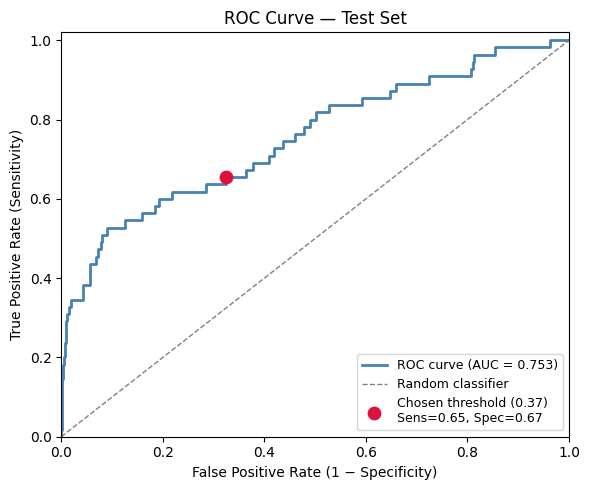

In [34]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test_true, y_test_probs)
roc_auc_val = auc(fpr, tpr)

# Find the point on the curve closest to our chosen threshold
chosen_idx = np.argmin(np.abs(roc_thresholds - threshold))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")
ax.scatter(
    fpr[chosen_idx], tpr[chosen_idx],
    color="crimson", zorder=5, s=80,
    label=f"Chosen threshold ({threshold:.2f})\nSens={sensitivity:.2f}, Spec={specificity:.2f}"
)
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

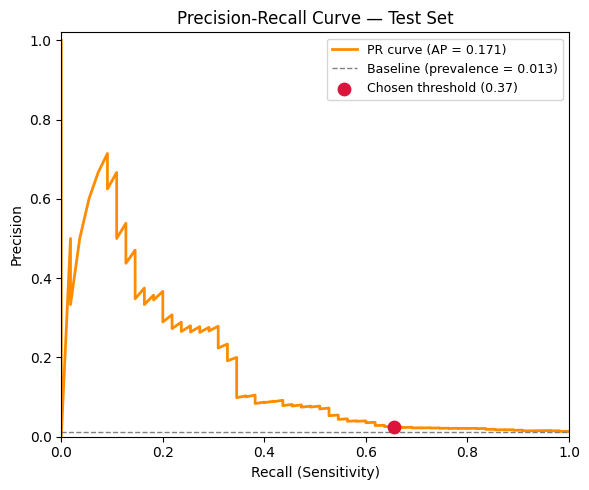

In [35]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test_true, y_test_probs)
ap = average_precision_score(y_test_true, y_test_probs)

# Closest point to chosen threshold (precision_recall_curve drops last threshold)
pr_chosen_idx = np.argmin(np.abs(pr_thresholds - threshold))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_curve, prec_curve, color="darkorange", lw=2, label=f"PR curve (AP = {ap:.3f})")
ax.axhline(y_test_true.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test_true.mean():.3f})")
ax.scatter(
    rec_curve[pr_chosen_idx], prec_curve[pr_chosen_idx],
    color="crimson", zorder=5, s=80,
    label=f"Chosen threshold ({threshold:.2f})"
)
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

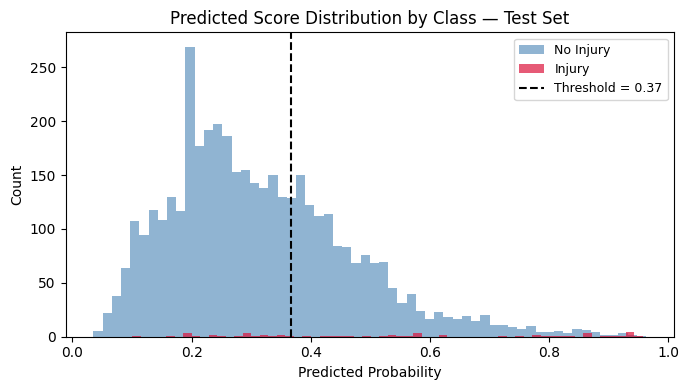

In [36]:
# Score Distribution by Class
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(y_test_probs[y_test_true == 0], bins=60, alpha=0.6, color="steelblue",  label="No Injury")
ax.hist(y_test_probs[y_test_true == 1], bins=60, alpha=0.7, color="crimson",    label="Injury")
ax.axvline(threshold, color="black", linestyle="--", lw=1.5, label=f"Threshold = {threshold:.2f}")

ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Predicted Score Distribution by Class — Test Set")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

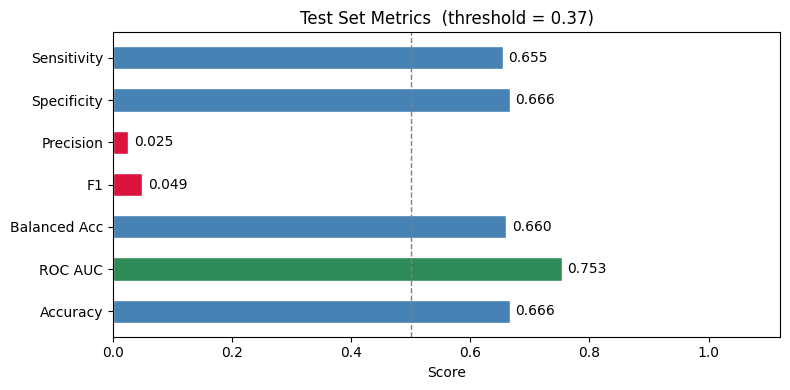

In [37]:
# Metrics Summary Bar Chart
metric_names  = ["Sensitivity", "Specificity", "Precision", "F1", "Balanced Acc", "ROC AUC", "Accuracy"]
metric_values = [sensitivity, specificity, precision, f1, balanced_acc, roc_auc, accuracy]
colors = ["crimson" if v < 0.5 else "steelblue" if v < 0.75 else "seagreen" for v in metric_values]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(metric_names, metric_values, color=colors, edgecolor="white", height=0.55)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Score")
ax.set_title(f"Test Set Metrics  (threshold = {threshold:.2f})")
ax.axvline(0.5, color="gray", linestyle="--", lw=1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()